# Phase 4: Storage + Hydropower Matching — Other Dams (1981)

**Goal:** Apply the joint storage + hydropower model to Comerford, Bellows Falls, and Wilder using the same three weighted cases used for Moore Dam:

- **Base**: $(\lambda_s,\lambda_m,\lambda_a)=(1.0, 0.0, 0.0)$
- **Balanced**: $(0.4, 0.3, 0.3)$
- **Hydro+**: $(0.2, 0.4, 0.4)$

Each dam is optimized independently for each case, and the outputs are organized to match the Moore Dam hydropower extension plots:
1. storage + monthly hydropower comparison by case  
2. trade-off plots (Storage RMSE vs Annual Bias, Storage RMSE vs Monthly Shape Loss)


In [13]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Find the project root so this notebook can run after cloning from GitHub.
# Expected structure: project_root/LM_26/...
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "LM_26":
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    while not (PROJECT_ROOT / "LM_26").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "LM_26").exists():
    raise FileNotFoundError(
        "Could not find the LM_26 folder. Open VS Code from the project root "
        "or update PROJECT_ROOT manually."
    )

sys.path.insert(0, str(PROJECT_ROOT))

PACKAGE_DIR = PROJECT_ROOT / "LM_26"
INPUT_DIR = PACKAGE_DIR / "experiment_inputs"
OUTPUT_DIR = PACKAGE_DIR / "experiment_outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
PARAM_DIR = OUTPUT_DIR / "params"

# Create output folders only if you later choose to save results/figures.
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PARAM_DIR.mkdir(parents=True, exist_ok=True)

from LM_26.hydro_optimizer import run_multistart
from LM_26.hydro_loss import compute_hydro_targets
from LM_26 import load_dam_data


## 1. Configuration

In [14]:
DAM_CONFIGS = {
    "Comerford": {
        "storage_file": INPUT_DIR / "Comerford_1981_converted_MCM.csv",
        "gen_file": INPUT_DIR / "Comerford_dam_monthly_generation.csv",
        "H_m": 54.864,
        "P_cap": 48.6 * 3,
        "eta": 0.8,
    },
    "BellowsFalls": {
        "storage_file": INPUT_DIR / "BellowsFalls_1981_converted_MCM.csv",
        "gen_file": INPUT_DIR / "BellowsFalls_dam_monthly_generation.csv",
        "H_m": 17.37,
        "P_cap": 13.6 * 3,
        "eta": 0.8,
    },
    "Wilder": {
        "storage_file": INPUT_DIR / "Wilder_1981_converted_MCM.csv",
        "gen_file": INPUT_DIR / "Wilder_dam_monthly_generation.csv",
        "H_m": 14.94,
        "P_cap": 16.2 * 3,  # smallest unit is ignored
        "eta": 0.8,
    },
}

CASES = {
    "Base": (1.0, 0.0, 0.0),
    "Balanced": (0.4, 0.3, 0.3),
    "Hydro+": (0.2, 0.4, 0.4),
}

OPT_SETTINGS = dict(
    num_runs = 20,
    learning_rate  = 1e-2,
    num_iterations = 20000,
    lam_smooth = 0.02,
    verbose = False,
)

months = np.arange(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


## 2. Run Base / Balanced / Hydro+ for Each Dam

In [ ]:
all_dam_case_results = {}

for dam_name, cfg in DAM_CONFIGS.items():
    print(f"\n{'='*70}")
    print(f"{dam_name}")
    print(f"{'='*70}")

    # Load daily storage/inflow data
    data, storage_obs, inflow, biweek_of_year, Smax = load_dam_data(cfg["storage_file"])
    sigma_S = float(jnp.std(storage_obs))

    # Month index aligned to simulation timeline (T-1 because hydro model compares to S_obs[1:])
    month_id_jax = jnp.array((data["time"].iloc[:-1].dt.month.values - 1).astype(int))

    # Load observed monthly generation
    obs_df = pd.read_csv(cfg["gen_file"])
    obs_df["month"] = pd.to_datetime(obs_df["period"], format="%Y-%m")
    obs_df["moy"] = obs_df["month"].dt.month
    obs_clim = (
        obs_df.groupby("moy", as_index=False)["gross-generation"]
        .mean()
        .sort_values("moy")
    )
    obs_monthly_mwh = obs_clim["gross-generation"].values.astype(float)
    annual_obs_mwh = float(obs_monthly_mwh.sum())
    obs_frac_12_jax = jnp.array(obs_monthly_mwh / annual_obs_mwh)

    case_results = {}

    for case_name, (lam_s, lam_m, lam_a) in CASES.items():
        print(f"\n--- {case_name} | λs={lam_s}, λm={lam_m}, λa={lam_a} ---")

        best_params, all_runs, summary = run_multistart(
            inflow_data = inflow,
            storage_obs_data = storage_obs,
            biweek_data = biweek_of_year,
            Smax = Smax,
            month_id_jax = month_id_jax,
            obs_frac_12_jax = obs_frac_12_jax,
            annual_obs_mwh = annual_obs_mwh,
            sigma_S = sigma_S,
            H_m = cfg["H_m"],
            P_cap = cfg["P_cap"],
            eta = cfg["eta"],
            lam_storage = lam_s,
            lam_hydro_shape = lam_m,
            lam_hydro_annual = lam_a,
            **OPT_SETTINGS,
        )

        safe_case = case_name.replace('+', 'plus').replace(' ', '_')
        save_path = PARAM_DIR / f"{dam_name}_{safe_case}_best_params.npy"

        np.save(save_path, np.array(best_params))
        print(f"Saved: {save_path}")

        case_results[case_name] = {
            "best_params": best_params,
            "all_runs": all_runs,
            "summary": summary,
            "metrics": summary["best_metrics"],
            "data": data,
            "storage_obs": storage_obs,
            "obs_frac_12": np.array(obs_frac_12_jax),
            "annual_obs_mwh": annual_obs_mwh,
            "lambdas": (lam_s, lam_m, lam_a),
        }

    all_dam_case_results[dam_name] = case_results
    print(f"\n{dam_name} complete.")



Comerford
Loaded 365 days from: /Users/liyingma/MEng_Project/LM_26/experiment_inputs/Comerford_1981_converted_MCM.csv
S0 = 36.40 MCM
Smax = 39.80 MCM  (proxy from observed max)
Mean inflow = 8.30 MCM/day

--- Base | λs=1.0, λm=0.0, λa=0.0 ---

--- Seed 1/20 (seed=0) ---
Total Loss: 0.4411 | Storage RMSE: 3.349 MCM | Annual Bias: 2.98% | Shape Loss: 0.0746

--- Seed 2/20 (seed=1) ---
Total Loss: 0.4411 | Storage RMSE: 3.349 MCM | Annual Bias: 2.98% | Shape Loss: 0.0747

--- Seed 3/20 (seed=2) ---
Total Loss: 0.4411 | Storage RMSE: 3.349 MCM | Annual Bias: 2.98% | Shape Loss: 0.0747

--- Seed 4/20 (seed=3) ---
Total Loss: 0.3610 | Storage RMSE: 3.030 MCM | Annual Bias: 2.98% | Shape Loss: 0.0741

--- Seed 5/20 (seed=4) ---
Total Loss: 0.3610 | Storage RMSE: 3.030 MCM | Annual Bias: 2.98% | Shape Loss: 0.0741

--- Seed 6/20 (seed=5) ---
Total Loss: 0.3611 | Storage RMSE: 3.030 MCM | Annual Bias: 2.98% | Shape Loss: 0.0741

--- Seed 7/20 (seed=6) ---
Total Loss: 0.3610 | Storage RMSE: 3.0

## 3. Storage + Monthly Hydropower Plots by Dam and Case

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Comerford_Base_hydro_case.png


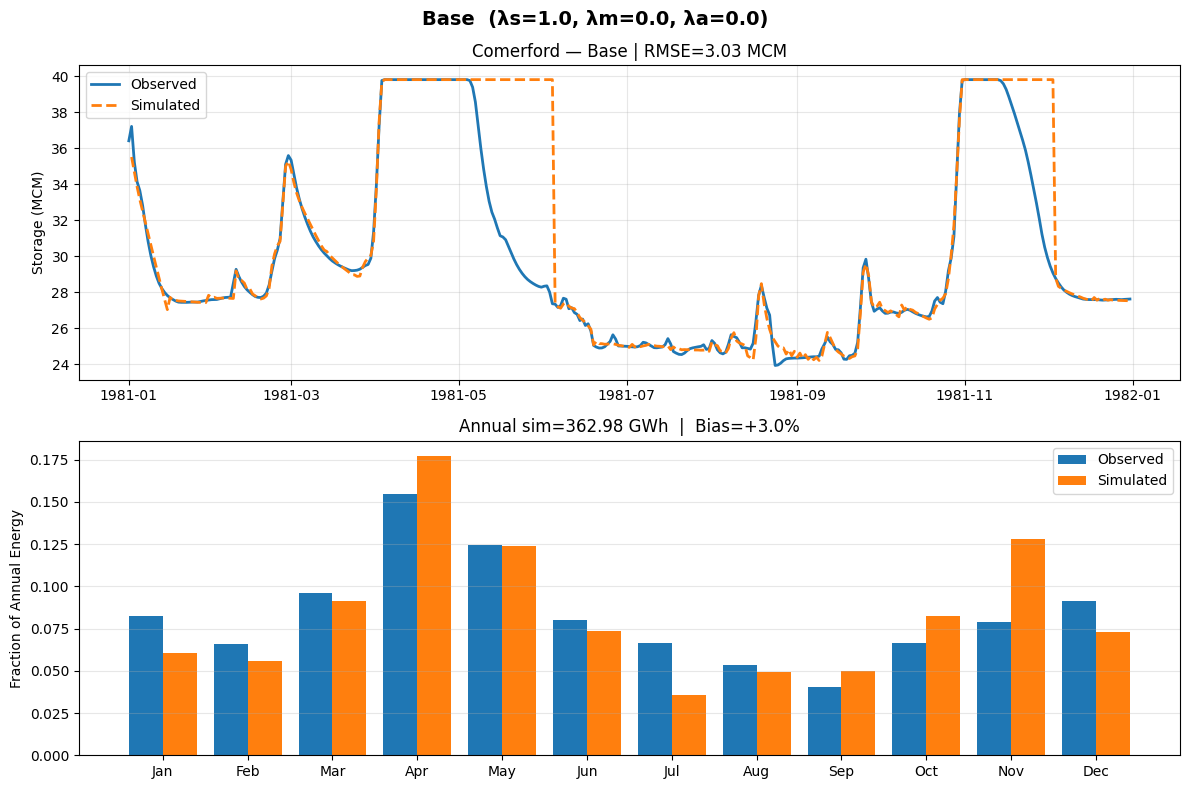

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Comerford_Balanced_hydro_case.png


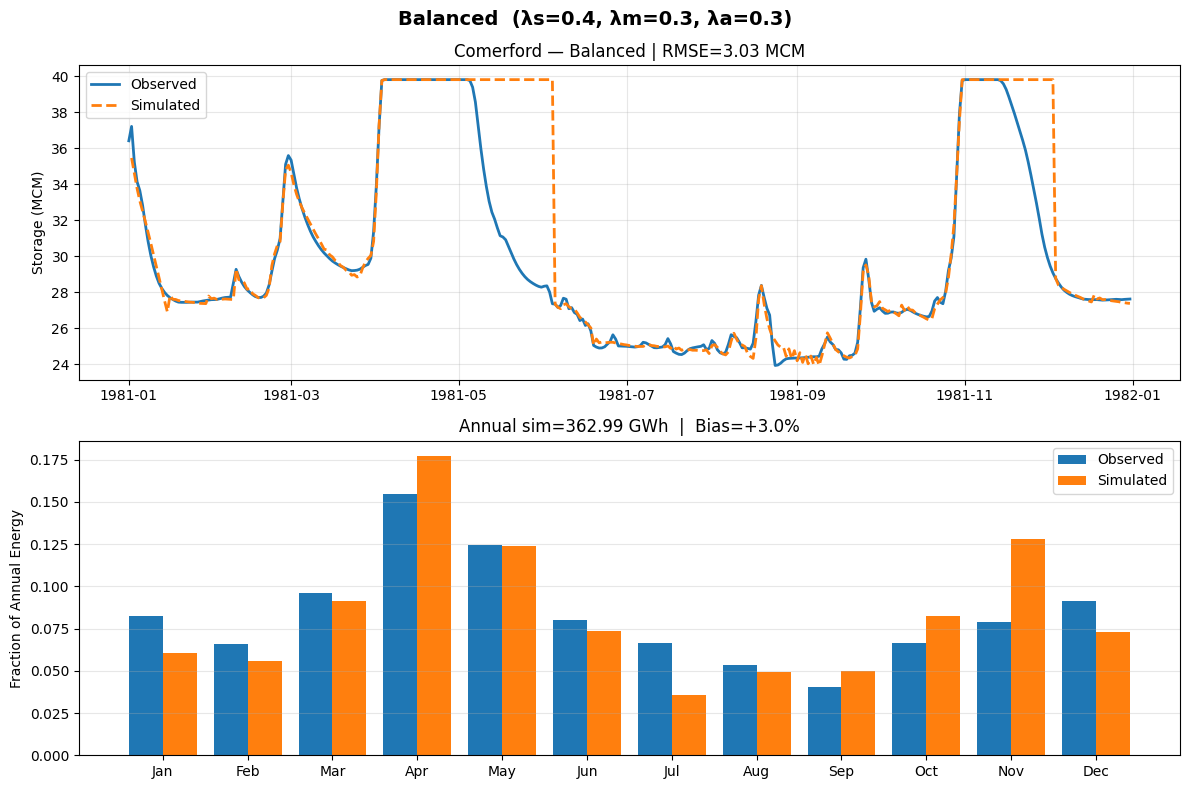

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Comerford_Hydroplus_hydro_case.png


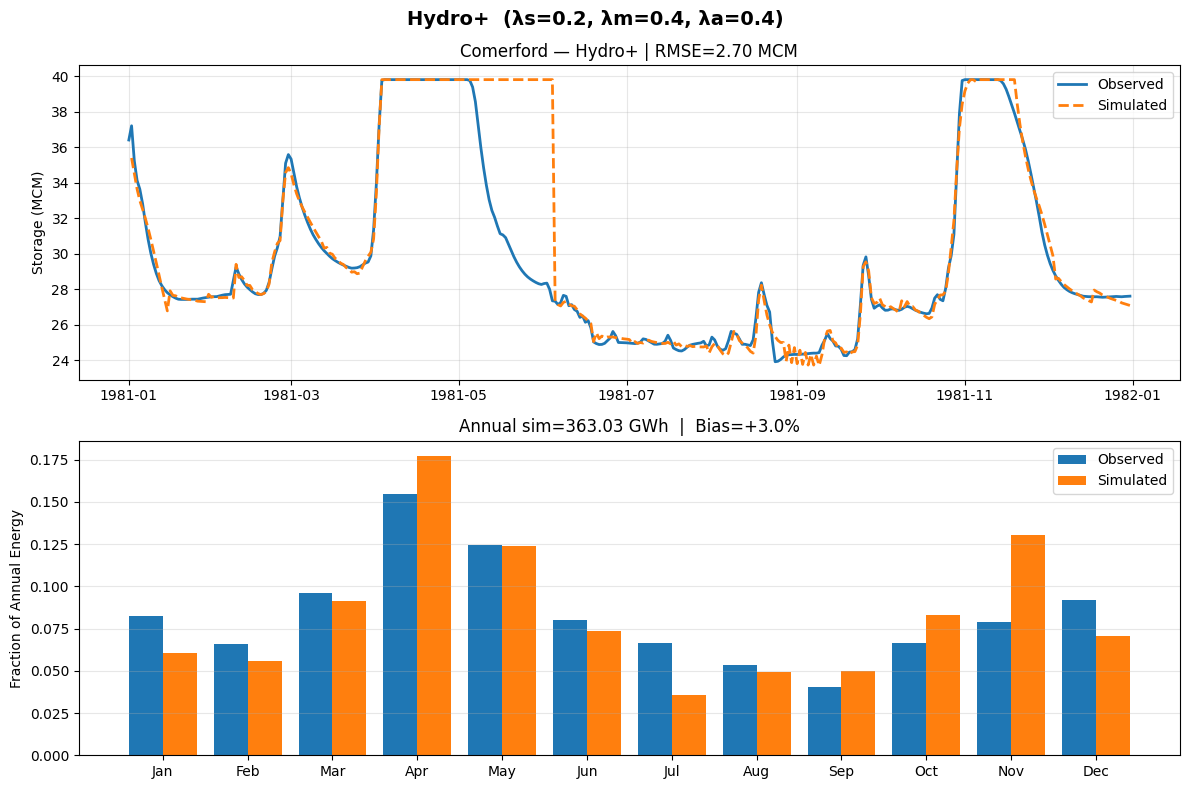

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/BellowsFalls_Base_hydro_case.png


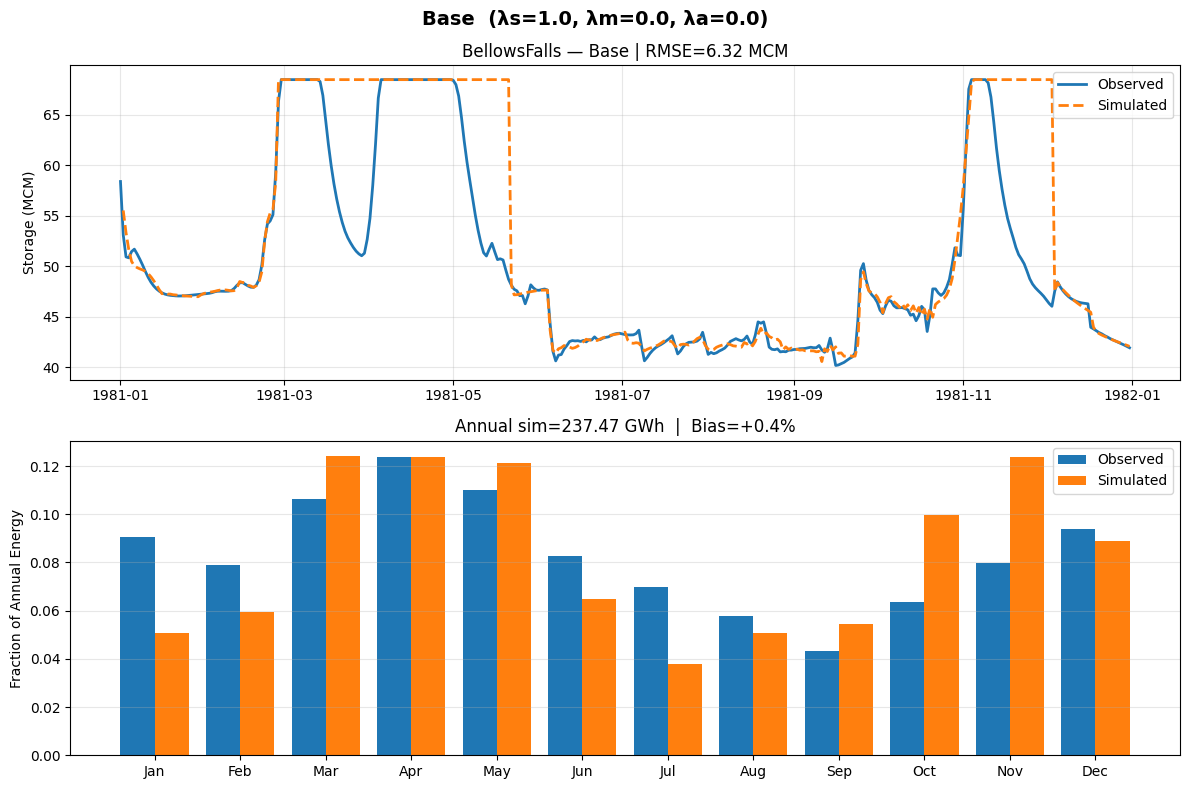

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/BellowsFalls_Balanced_hydro_case.png


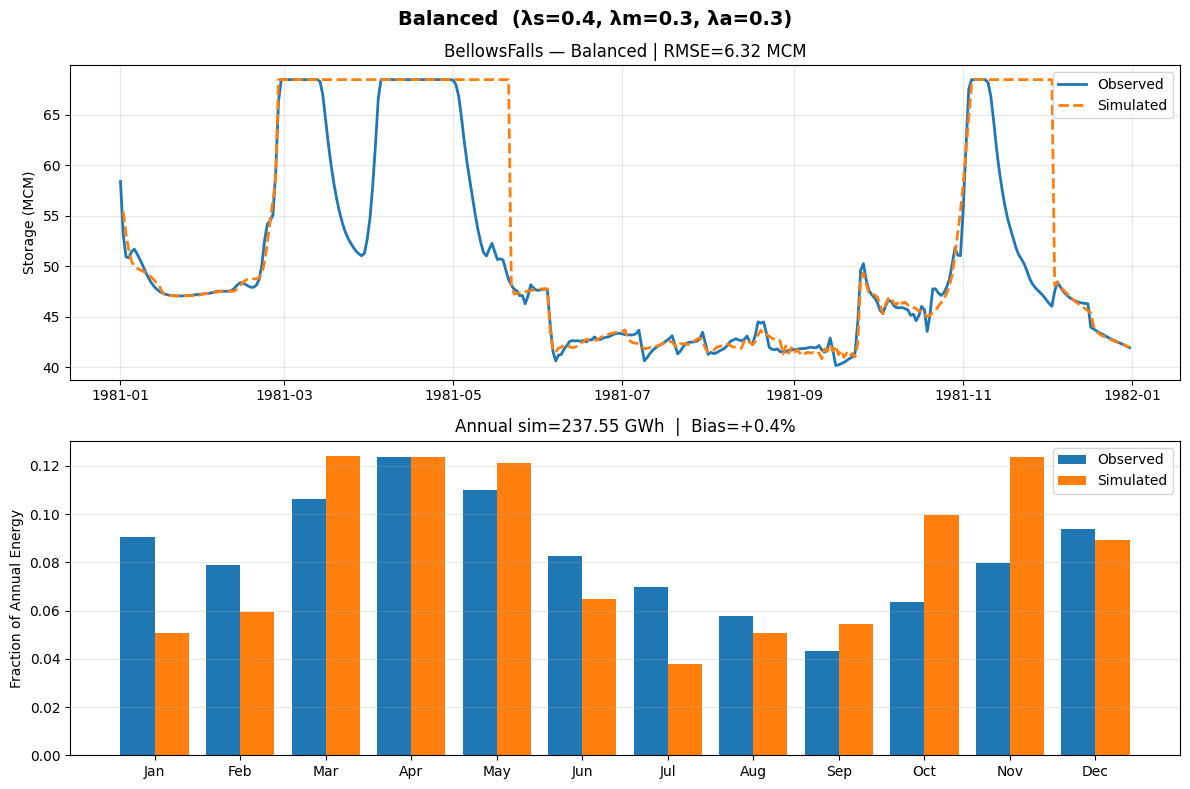

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/BellowsFalls_Hydroplus_hydro_case.png


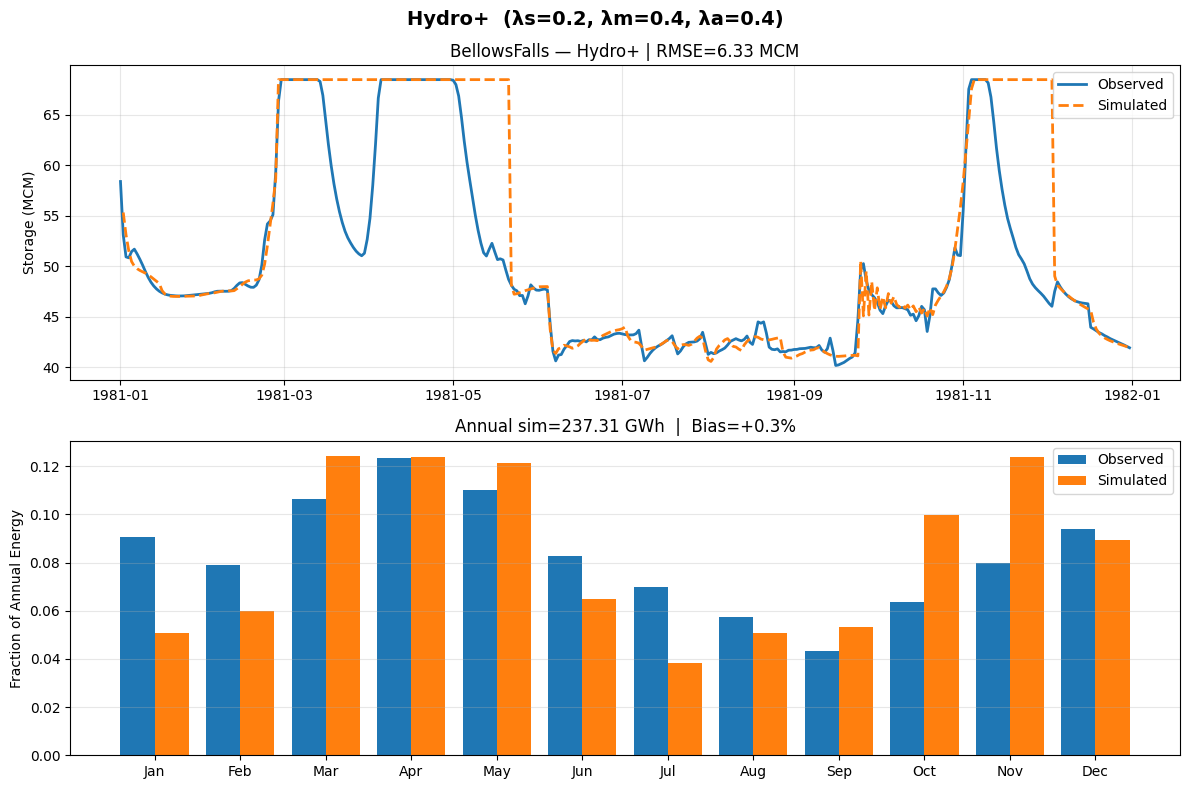

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Wilder_Base_hydro_case.png


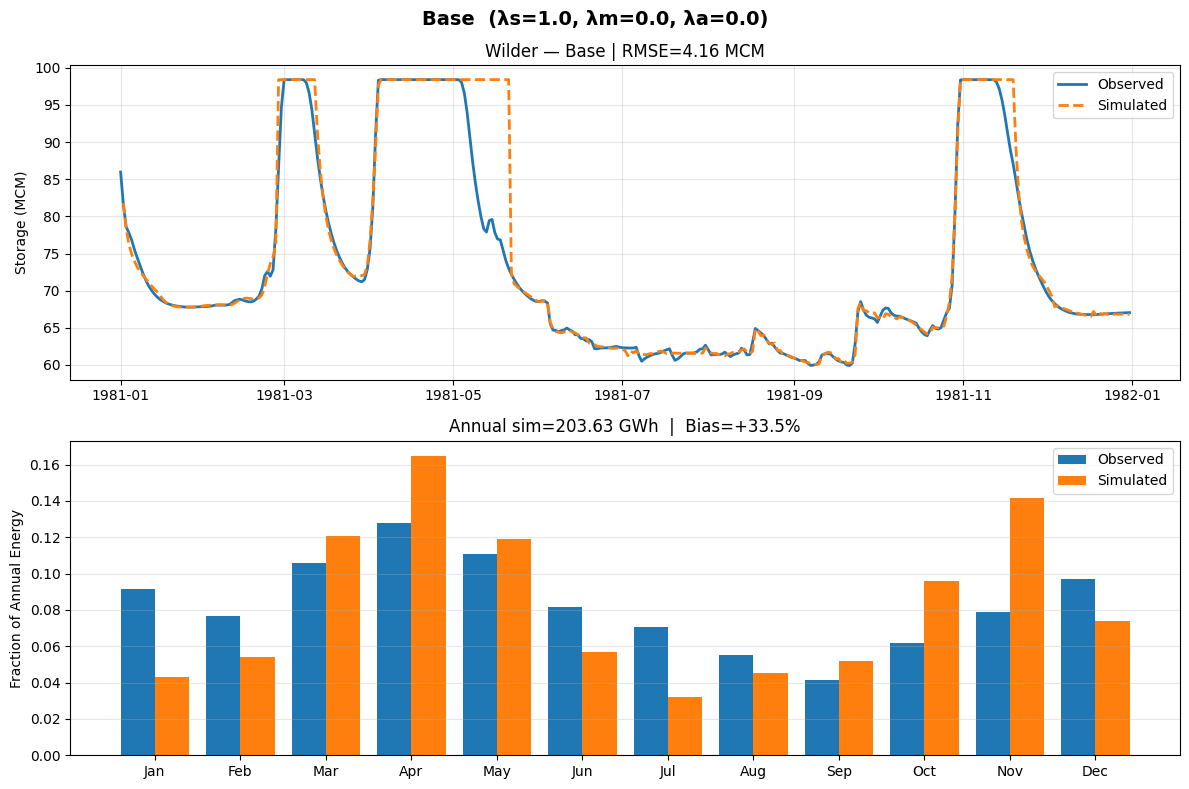

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Wilder_Balanced_hydro_case.png


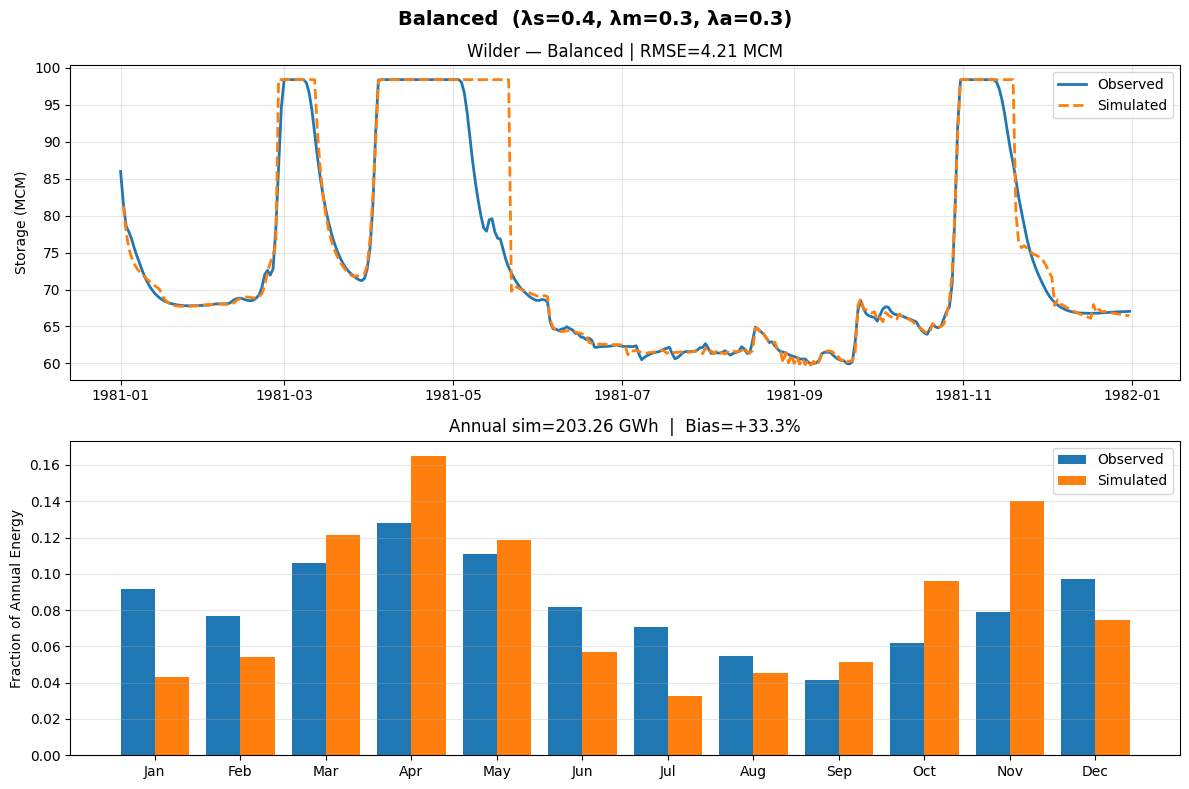

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Wilder_Hydroplus_hydro_case.png


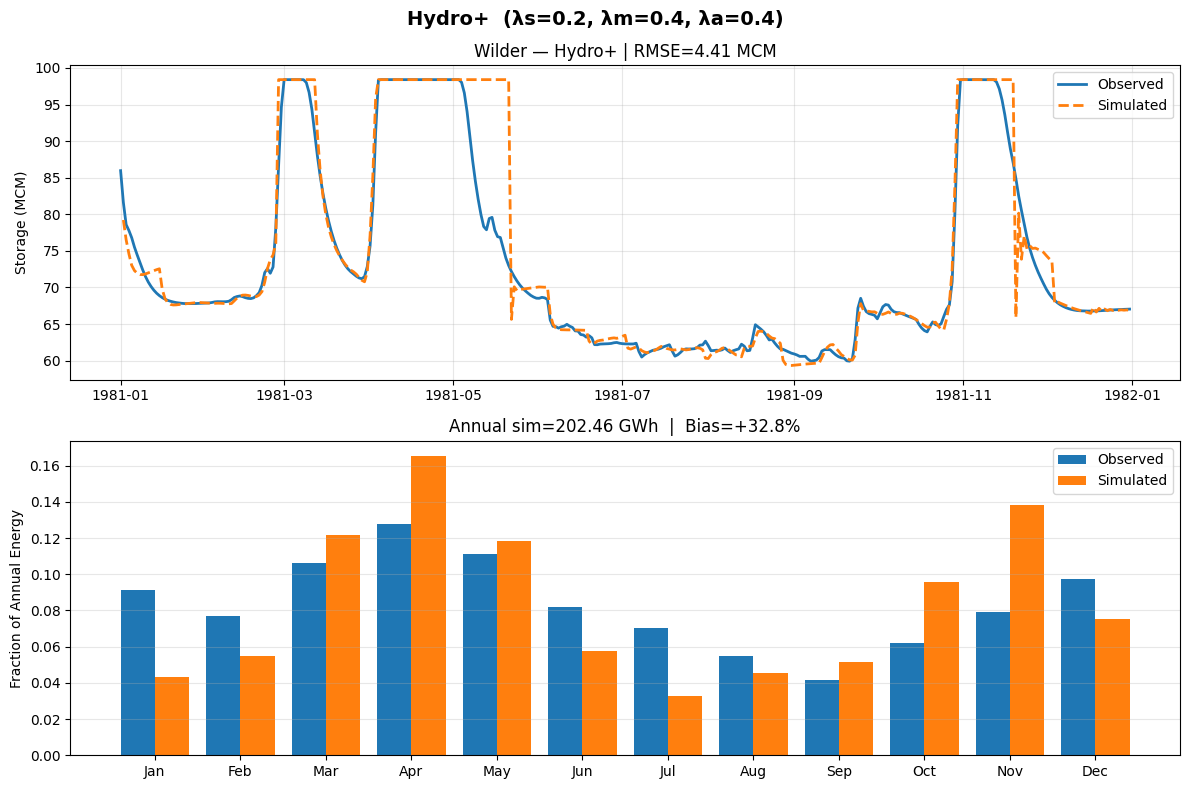

In [18]:
for dam_name, case_dict in all_dam_case_results.items():
    for case_name in ["Base", "Balanced", "Hydro+"]:
        r = case_dict[case_name]
        m = r["metrics"]
        data = r["data"]
        storage_obs = np.array(r["storage_obs"])
        lam_s, lam_m, lam_a = r["lambdas"]

        fig, axes = plt.subplots(2, 1, figsize=(12, 8))

        # Storage panel
        axes[0].plot(data["time"], storage_obs, color="tab:blue", linewidth=2, label="Observed")
        axes[0].plot(data["time"].values[1:], m["S_sim"], color="tab:orange", linestyle="--", linewidth=2, label="Simulated")
        axes[0].set_ylabel("Storage (MCM)")
        axes[0].set_title(f"{dam_name} — {case_name} | RMSE={m['storage_rmse']:.2f} MCM")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # Monthly hydropower panel
        axes[1].bar(months - 0.2, r["obs_frac_12"], width=0.4, color="tab:blue", label="Observed")
        axes[1].bar(months + 0.2, m["sim_frac_12"], width=0.4, color="tab:orange", label="Simulated")
        axes[1].set_xticks(months)
        axes[1].set_xticklabels(month_names)
        axes[1].set_ylabel("Fraction of Annual Energy")
        axes[1].set_title(f"Annual sim={m['annual_sim_gwh']:.2f} GWh  |  Bias={m['bias_percent']:+.1f}%")
        axes[1].legend()
        axes[1].grid(alpha=0.3, axis="y")

        plt.suptitle(f"{case_name}  (λs={lam_s}, λm={lam_m}, λa={lam_a})",
                     fontsize=14, fontweight="bold")
        plt.tight_layout()

        safe_case = case_name.replace('+', 'plus').replace(' ', '_')
        out_path = FIGURE_DIR / f"{dam_name}_{safe_case}_hydro_case.png"
        
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {out_path}")
        plt.show()


> **Note:** The Base case is not a direct reproduction of the Phase 2 storage-matching results, even though both are storage-only. This is because the hydro loss function uses a normalized MSE rather than RMSE, which is necessary to keep the storage term on a comparable scale with the hydropower terms. As a result, the Phase 2 storage-matching results should be used as the storage-only baseline for comparison.

## 5. Trade-off Plots by Dam

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Comerford_tradeoff_bias.png


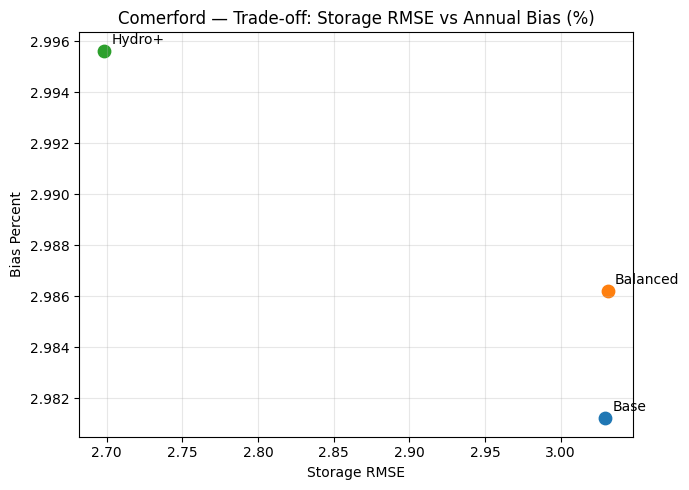

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Comerford_tradeoff_monthly.png


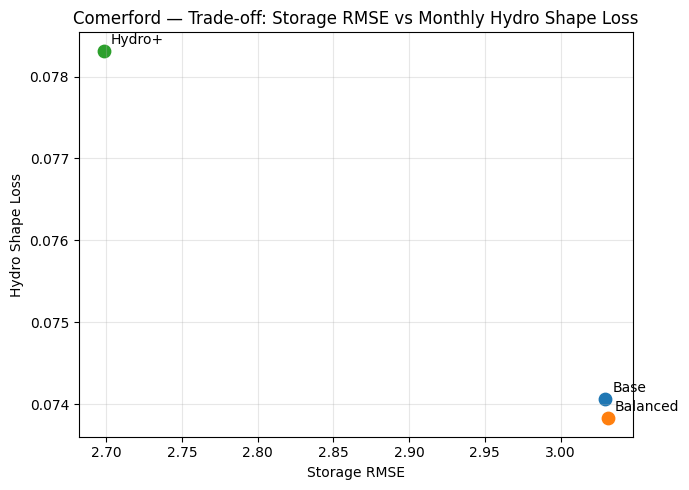

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/BellowsFalls_tradeoff_bias.png


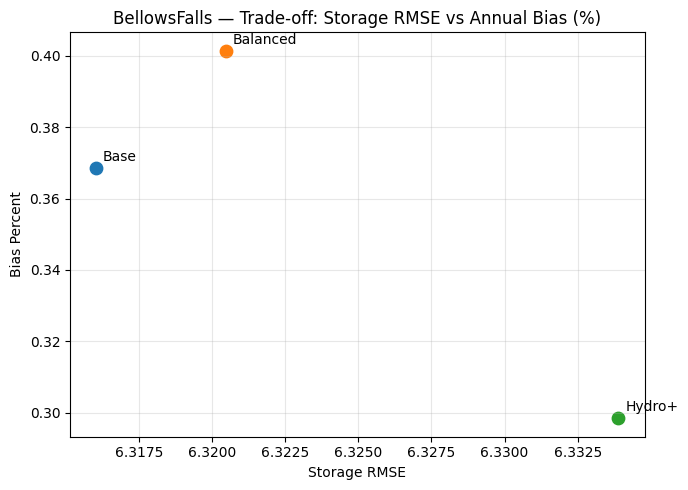

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/BellowsFalls_tradeoff_monthly.png


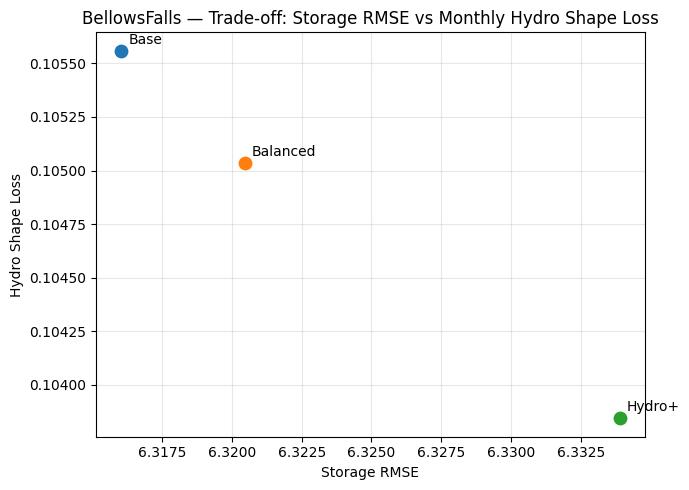

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Wilder_tradeoff_bias.png


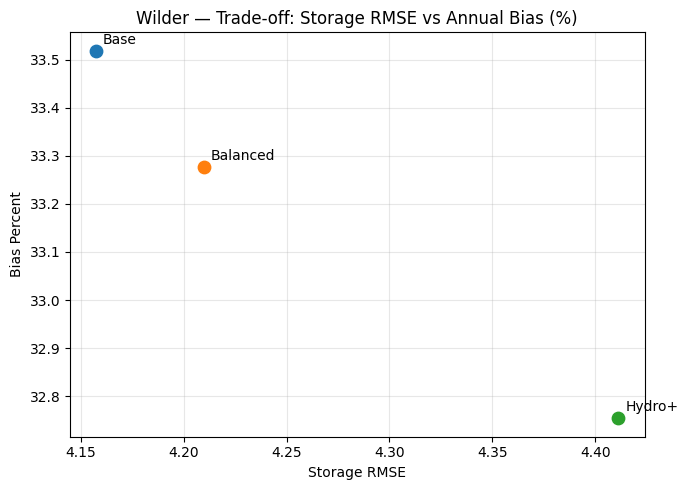

Saved: /Users/liyingma/MEng_Project/LM_26/experiment_outputs/figures/Wilder_tradeoff_monthly.png


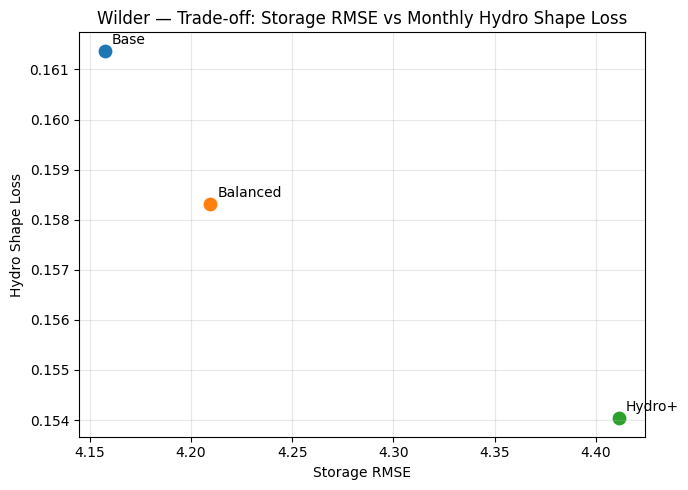

In [20]:
for dam_name, case_dict in all_dam_case_results.items():
    # Trade-off 1: Storage RMSE vs Annual Bias
    plt.figure(figsize=(7, 5))
    for case_name in ["Base", "Balanced", "Hydro+"]:
        m = case_dict[case_name]["metrics"]
        plt.scatter(m["storage_rmse"], m["bias_percent"], s=80, label=case_name)
        plt.annotate(case_name, (m["storage_rmse"], m["bias_percent"]),
                     textcoords="offset points", xytext=(5, 5))
    plt.xlabel("Storage RMSE")
    plt.ylabel("Bias Percent")
    plt.title(f"{dam_name} — Trade-off: Storage RMSE vs Annual Bias (%)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    out_path = FIGURE_DIR / f"{dam_name}_tradeoff_bias.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

    # Trade-off 2: Storage RMSE vs Monthly Hydro Shape Loss
    plt.figure(figsize=(7, 5))
    for case_name in ["Base", "Balanced", "Hydro+"]:
        m = case_dict[case_name]["metrics"]
        plt.scatter(m["storage_rmse"], m["hydro_shape_loss"], s=80, label=case_name)
        plt.annotate(case_name, (m["storage_rmse"], m["hydro_shape_loss"]),
                     textcoords="offset points", xytext=(5, 5))
    plt.xlabel("Storage RMSE")
    plt.ylabel("Hydro Shape Loss")
    plt.title(f"{dam_name} — Trade-off: Storage RMSE vs Monthly Hydro Shape Loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    out_path = FIGURE_DIR / f"{dam_name}_tradeoff_monthly.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()
